In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
dataset_path = "../dataset/Indian"

In [3]:
print("Dataset Path :", dataset_path)
print("Path Exists :", os.path.exists(dataset_path))

Dataset Path : ../dataset/Indian
Path Exists : True


In [4]:
classes = sorted([
    folder
    for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Total Classes :", len(classes))
print(classes)

Total Classes : 35
['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [5]:
image_counts = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    count = len([
        img for img in os.listdir(class_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    image_counts.append([cls, count])

df = pd.DataFrame(image_counts, columns=["Class", "Images"])

df

,Class,Images
0,1,1200
1,2,1200
2,3,1200
3,4,1200
4,5,1200
5,6,1200
6,7,1200
7,8,1200
8,9,1200
9,A,1200


In [6]:
print("Total Classes :", len(df))
print("Total Images :", df["Images"].sum())
print("Average Images Per Class :", round(df["Images"].mean(), 2))

Total Classes : 35
Total Images : 42745
Average Images Per Class : 1221.29


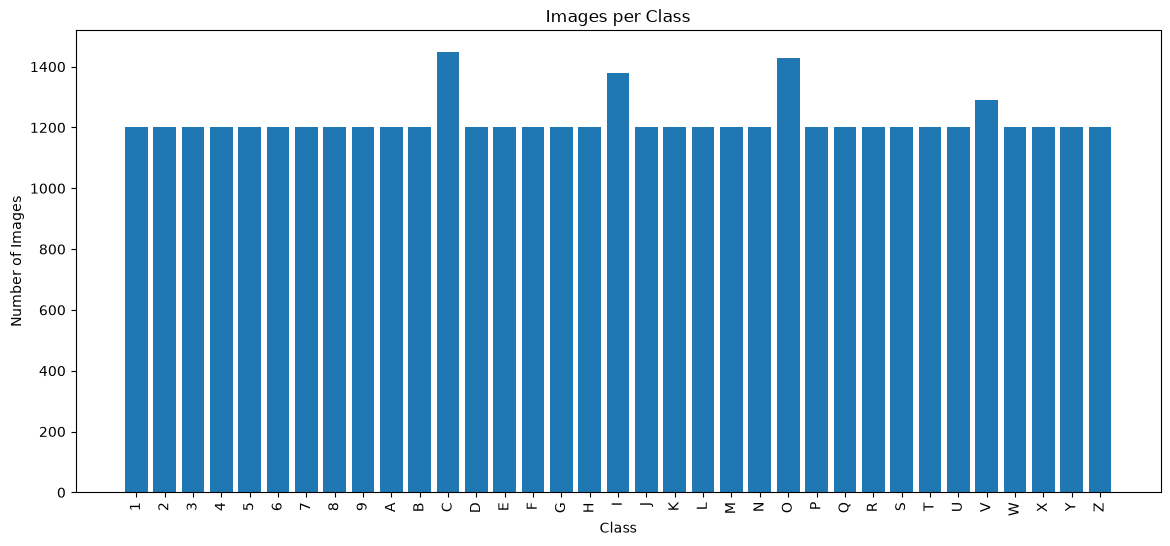

In [7]:
plt.figure(figsize=(14,6))

plt.bar(df["Class"], df["Images"])

plt.title("Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=90)

plt.show()

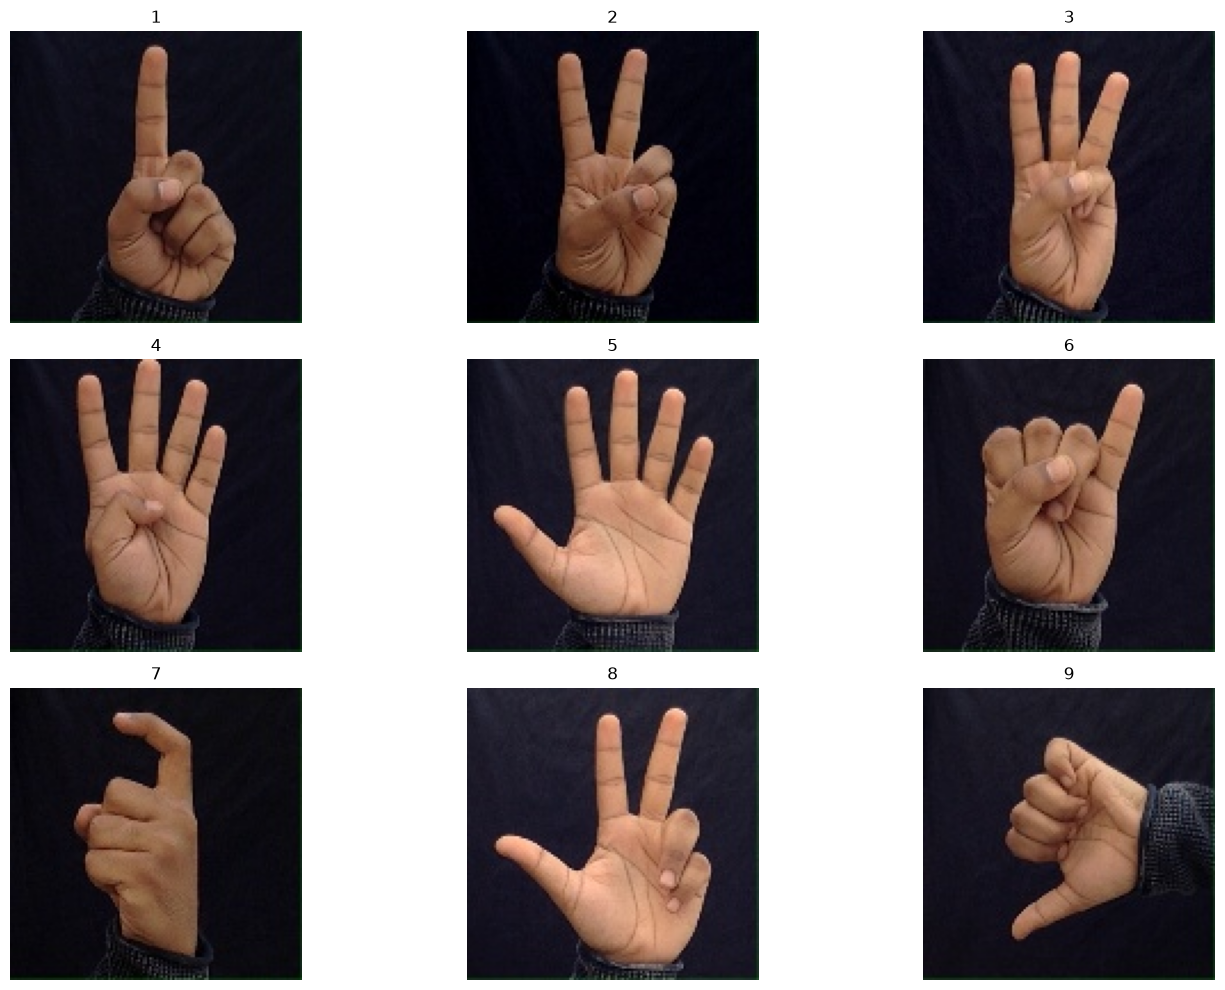

In [8]:
import random

plt.figure(figsize=(15, 10))

for i, cls in enumerate(classes[:9]):   # First 9 classes
    class_path = os.path.join(dataset_path, cls)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
image_sizes = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path)

        image_sizes.append(img.size)

print("Minimum Size :", min(image_sizes))
print("Maximum Size :", max(image_sizes))

Minimum Size : (128, 128)
Maximum Size : (1920, 1088)


In [10]:
sample_path = os.path.join(
    dataset_path,
    classes[0],
    os.listdir(os.path.join(dataset_path, classes[0]))[0]
)

img = cv2.imread(sample_path)

print("Image Shape :", img.shape)


Image Shape : (128, 128, 3)


In [11]:
corrupted = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            corrupted.append(img_path)

print("Corrupted Images :", len(corrupted))

Corrupted Images : 0


In [12]:
print("="*40)
print("DATASET REPORT")
print("="*40)

print(f"Total Classes : {len(classes)}")
print(f"Total Images  : {df['Images'].sum()}")
print(f"Average Images/Class : {round(df['Images'].mean(),2)}")
print(f"Minimum Images/Class : {df['Images'].min()}")
print(f"Maximum Images/Class : {df['Images'].max()}")

DATASET REPORT
Total Classes : 35
Total Images  : 42745
Average Images/Class : 1221.29
Minimum Images/Class : 1200
Maximum Images/Class : 1447


In [13]:
from collections import Counter

size_counts = Counter(image_sizes)

print("Top 10 Most Common Image Sizes:\n")

for size, count in size_counts.most_common(10):
    print(size, ":", count)

Top 10 Most Common Image Sizes:

(128, 128) : 42000
(640, 480) : 476
(1088, 1920) : 179
(1920, 1088) : 90


In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt

I0000 00:00:1784466885.738414   17009 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784466885.744091   17009 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784466886.103457   17009 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784466888.788708   17009 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

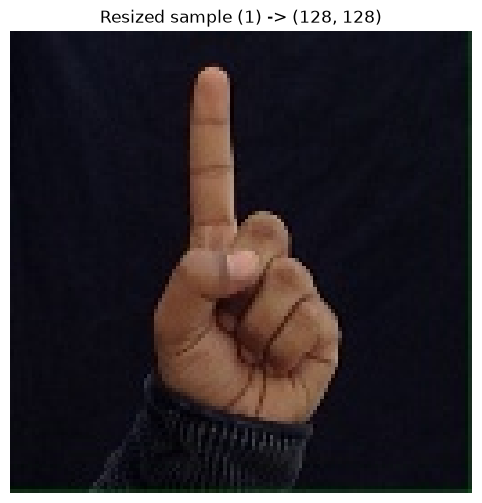

In [15]:
IMG_SIZE = (128, 128)

# FIX: define an explicit sample path instead of relying on a leftover
# `img_path` variable from an earlier loop (corrupted-images check).
sample_class = classes[0]
sample_class_path = os.path.join(dataset_path, sample_class)
sample_img_name = os.listdir(sample_class_path)[0]
sample_img_path = os.path.join(sample_class_path, sample_img_name)

img = cv2.imread(sample_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, IMG_SIZE)

plt.imshow(img)
plt.title(f"Resized sample ({sample_class}) -> {IMG_SIZE}")
plt.axis('off')
plt.show()

In [16]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

## Fixed 3-Way Split (Train / Validation / Test)

Pehle sirf train/val split tha. Ab `validation_split=0.3` se ek bada temp holdout banate hain, phir usko val/test me 50-50 baant dete hain (15% val, 15% test).

In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

holdout_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split the 30% holdout into two equal halves: validation and test
holdout_batches = tf.data.experimental.cardinality(holdout_ds).numpy()
val_ds = holdout_ds.take(holdout_batches // 2)
test_ds = holdout_ds.skip(holdout_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches :", tf.data.experimental.cardinality(test_ds).numpy())

Found 42745 files belonging to 35 classes.
Using 29922 files for training.


E0000 00:00:1784466891.516516   17009 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 42745 files belonging to 35 classes.
Using 12823 files for validation.
Train batches: 936
Val batches  : 200
Test batches : 201


In [18]:
class_names = train_ds.class_names

print(class_names)
print("Total Classes:", len(class_names))

['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Total Classes: 35


In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Normalization (Rescaling)

Pixel values abhi 0-255 range me hain. Model training ke liye 0-1 range me rescale karna zaroori hai — isko ek Keras layer ke through karte hain taaki ye training/inference dono me automatically apply ho (manual preprocessing bhoolne ka risk nahi rahega).

In [20]:
rescale_layer = tf.keras.layers.Rescaling(1./255)

# Example usage (model ke first layer me use hoga):
# model = tf.keras.Sequential([rescale_layer, ...])

# Quick sanity check on one batch
for images, labels in train_ds.take(1):
    rescaled = rescale_layer(images)
    print("Before rescale -> min:", images.numpy().min(), "max:", images.numpy().max())
    print("After  rescale -> min:", rescaled.numpy().min(), "max:", rescaled.numpy().max())

Before rescale -> min: 0.0 max: 255.0
After  rescale -> min: 0.0 max: 1.0


## Data Augmentation

Sign language images me hand ka orientation, lighting, aur position vary karta hai. Thoda augmentation (flip, rotation, zoom, contrast) model ko generalize karne me madad karega. Note: horizontal flip agar left/right hand-specific signs hain to sochke use karo — kuch signs flip karne se meaning badal sakta hai.

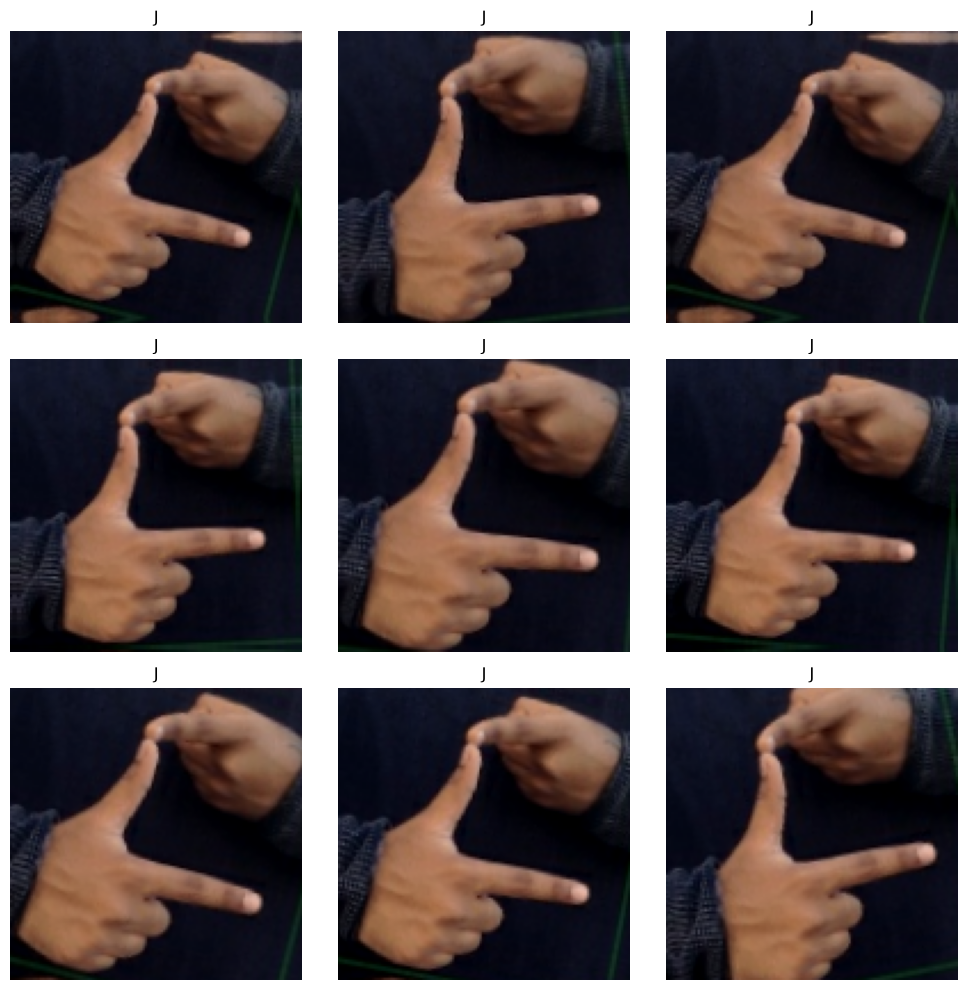

In [21]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

# Preview augmented samples
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        augmented = data_augmentation(images)
        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented[0].numpy().astype("uint8"))
        plt.title(class_names[labels[0]])
        plt.axis("off")
plt.tight_layout()
plt.show()

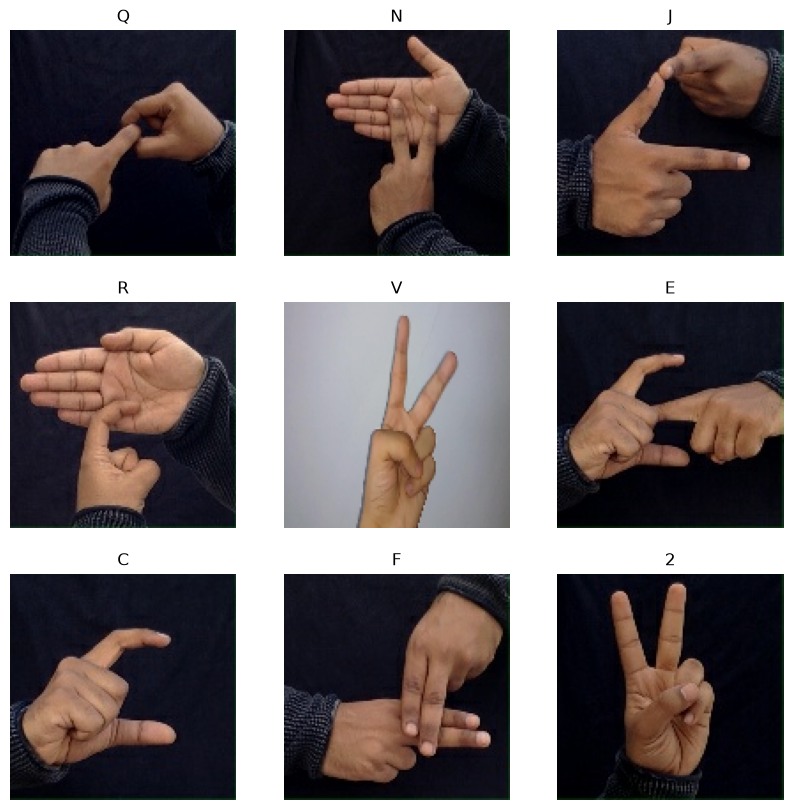

In [22]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Summary & Next Steps

**Is EDA notebook me fix kiya gaya:**
- Leaked `img_path` variable bug fix
- Proper Train (70%) / Validation (15%) / Test (15%) split
- Rescaling layer (0-1 normalization)
- Data augmentation preview

**Aage ka kaam (02_Model.ipynb me):**
1. CNN model architecture define karo (rescale_layer + data_augmentation + Conv2D blocks) ya transfer learning (MobileNetV2 / EfficientNetB0) try karo
2. `train_ds`, `val_ds` se model train karo, callbacks (EarlyStopping, ModelCheckpoint) use karo
3. Training ke baad `test_ds` par final evaluation karo (sirf ek baar, end me)
4. Confusion matrix aur per-class accuracy dekho — kahin similar-looking signs (jaise M/N, U/V) confuse to nahi ho rahe
5. Agar GPU available ho to training use karo (abhi CPU par chal raha tha)